In [52]:
# helper functions are at the top
# all cells after wards runs the different cases
# 
import numpy as np
import matplotlib.pyplot as plt


# helper functions


def stepFunction(y):  # represents step function
    if y >= 0:
        return 1
    else:
        return 0


def parseLabels(file):  # parse the labels form the labels file for use
    labels = None
    with open(file, "rb") as f:
        f.read(8)  # skip the buffer according the mnist pdf
        labels = np.frombuffer(f.read(), dtype=np.int8) # create array of labels
    return labels


def parsePixels(file):  # parse the images from the images file for use
    pixels = None
    with open(file, "rb") as f:
        f.read(16)  # skip the buffer according the mnist pdf
        pixels = np.frombuffer(f.read(), dtype=np.uint8)
        pixels = pixels.reshape(-1, 28, 28)  # creates array of matrixes each being 28 by 28
    return pixels


class neural_network:
    def __init__(self):
        # epoch 0 at index 0 is set to 0 for the errors
        self.errors = []
        self.errors.append(0)
        # epoch set to zero
        self.epoch = 0
        # random weights set between -0.5 and 0.5
        self.weights = np.random.uniform(-0.1, 0.1, (10, 784))  # hard coded 784 because each image given has 784 pixels

    def reset(self):
        # rest variables if needed for more tests
        self.errors = []
        self.errors.append(0)
        self.epoch = 0
        self.weights = np.random.uniform(-0.1, 0.1, (10, 784))

    def train(self, n, lr, hold, imagePath, labelPath):
        self.reset()  # reset values if you're training multiple times
        # get images and labels
        images = parsePixels(imagePath)
        labels = parseLabels(labelPath)

        while True:  #3.1
            for i in range(n):  # 3.1.1 first for loop to predict label with just the greatest induced field
                currentImage = images[i].flatten()  # converts 28x28 matrix into flat array 1x784
                desired = labels[i]  # get correct label for this image
                prediction = np.dot(self.weights, currentImage)  # 1x10 array of local induced field of each output neuron
                prediction = np.argmax(prediction)  # get index of greatest value
                if desired != prediction:  # increment error count if misclassified
                    self.errors[self.epoch] += 1

            self.epoch += 1  # 3.1.2
            self.errors.append(0)

            for i in range(n):  # 3.1.3 second for loop to update weights
                currentImage = images[i].flatten()  # converts 28x28 matrix into flat array 1x784

                temp = np.dot(self.weights, currentImage)  # 1x10 array of local induced field of each output neuron
                prediction = np.zeros(10)
                for y in range(len(prediction)):
                    prediction[y] = stepFunction(temp[y])

                # reformat desired into array for next calculation
                desired = np.zeros(10)
                desired[labels[i]] = 1

                self.weights = self.weights + lr * np.outer(desired - prediction, currentImage)
            #print((self.errors[self.epoch - 1] / n))
            if (self.errors[self.epoch - 1] / n) <= hold:  # 3.2 continues to 3.1 if false
                return (self.errors[self.epoch-1] / n) * 100 # print out the final result
            if self.epoch >=1000:  # this is here to stop the function from running too long
                return (self.errors[self.epoch-1] / n) * 100
            

    def test(self, imagePath, labelPath):
        # open images and labels
        images = parsePixels(imagePath)
        labels = parseLabels(labelPath)
        errors = 0
        for i in range(len(images)):
            currentImage = images[i].flatten()  # converts 28x28 matrix into flat array 1x784
            # get actual label for this image
            desired = labels[i]

            # compute the dot product of the weights and current image
            prediction = np.dot(self.weights, currentImage)
            # get the largest induced field and record as prediction
            prediction = np.argmax(prediction)

            if desired != prediction: # increment error count if not matching
                errors += 1

            # return percentage of errors for testing data
        return errors / len(images) * 100
    
    def plot(self):  # function used to plot errors and epochs
        plt.plot(self.errors)
        plt.xlabel("epoch")  # x axis label
        plt.ylabel("errors")  # y axis label
        plt.show()

training error:  0.0 %
testing error:  45.85 %


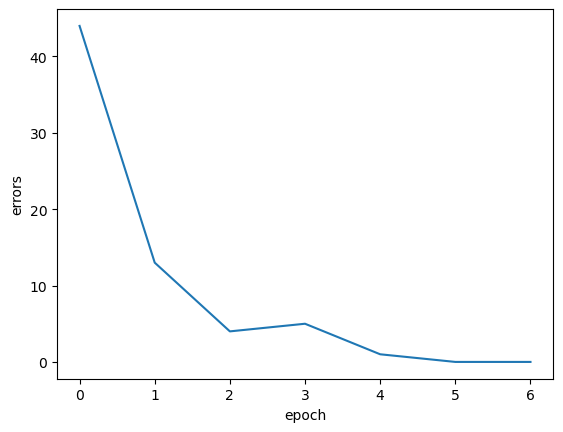

In [57]:
# Part F
test50 = neural_network() # create class 
trainingError50 = test50.train(50, 1, 0.001, 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte') # train the network
testingError50 = test50.test('t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte') # test network with testing data
print("training error: ", trainingError50, "%")  # print out the results
print("testing error: ", testingError50, "%")
test50.plot()  # call plot function to makes these graphs


training error:  0.1 %
testing error:  17.47 %


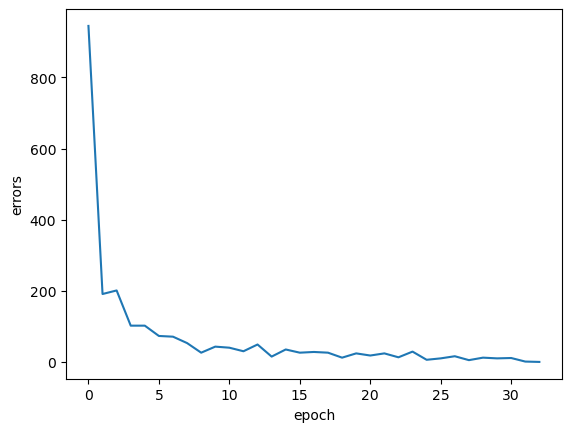

In [59]:
# Part G
test1000 = neural_network()
trainingError1000 = test1000.train(1000, 1, 0.001, 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte')
testingError1000 = test1000.test('t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte')
print("training error: ", trainingError1000, "%")
print("testing error: ", testingError1000, "%")
test1000.plot()

In [61]:
# Part H, this took 48 min bruh
test60000 = neural_network()
trainingError60000 = test60000.train(60000, 1, 0, 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte')
#testingError60000 = test60000.test('t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte')
print("training error: ", trainingError60000, "%")
#print("testing error: ", testingError60000, "%")
test60000.plot()

KeyboardInterrupt: 